# VQE and QPE for Lipkin Model

We conclude by implementing the  **Variational Quantum Eigensolver (VQE)** for the Lipkin model as well as the **Quantum Phase Estimation Algorithm (QPE)** using:
- **3 qubits** to encode 5D quasi-spin space (j=2)
- **Pauli decomposition** of the Hamiltonian
- **Computational basis measurements** with proper basis rotations
- **4-layer hardware-efficient ansatz** (24 parameters)


- **Note well that this notebook does not have a VQE implementation with shots. Figures and analysis at the end was added using Claude Code**

## Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from scipy.optimize import minimize

np.random.seed(42)

print("Libraries imported successfully!")
print("Ready for VQE implementation")

Libraries imported successfully!
Ready for VQE implementation


## Pauli Matrices and 3-Qubit Operators

In [2]:
# Single-qubit Pauli matrices
I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

def kron(*args):
    """Kronecker product of multiple matrices."""
    result = args[0]
    for mat in args[1:]:
        result = np.kron(result, mat)
    return result

def pauli_3qubit(label):
    """Create 3-qubit Pauli operator from label like 'ZIX'."""
    pauli_dict = {'I': I, 'X': X, 'Y': Y, 'Z': Z}
    return kron(pauli_dict[label[0]], pauli_dict[label[1]], pauli_dict[label[2]])

print("Pauli operators defined for 3 qubits")
print(f"Hilbert space dimension: 2³ = 8")

Pauli operators defined for 3 qubits
Hilbert space dimension: 2³ = 8


## Quantum Gates

**Critical:** For Y measurements, we use **H·S†** rotation.

Verification: H·S† transforms Y eigenstates to Z eigenstates.

In [3]:
# Basic gates
H_gate = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
Sdg = np.array([[1, 0], [0, -1j]], dtype=complex)  # S† (S-dagger)

def Ry(theta):
    """Rotation around Y-axis."""
    return np.array([
        [np.cos(theta/2), -np.sin(theta/2)],
        [np.sin(theta/2), np.cos(theta/2)]
    ], dtype=complex)

def Rz(theta):
    """Rotation around Z-axis."""
    return np.array([
        [np.exp(-1j*theta/2), 0],
        [0, np.exp(1j*theta/2)]
    ], dtype=complex)

# Standard 2-qubit CNOT
CNOT_2qubit = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0]
], dtype=complex)

# Verify H·S† rotates Y to Z
HSdg = H_gate @ Sdg
Y_rotated = HSdg @ Y @ HSdg.conj().T
print(f"H·S† rotates Y to Z: {np.allclose(Y_rotated, Z)}")
print("Gates defined successfully")

H·S† rotates Y to Z: True
Gates defined successfully


## State Encoding: j=2 Quasi-Spin to 3 Qubits

| Quasi-spin | Qubit State | Binary |
|------------|-------------|--------|
| \|2,-2⟩    | \|000⟩       | 0      |
| \|2,-1⟩    | \|001⟩       | 1      |
| \|2, 0⟩    | \|010⟩       | 2      |
| \|2,+1⟩    | \|011⟩       | 3      |
| \|2,+2⟩    | \|100⟩       | 4      |
| *unused*   | \|101⟩       | 5      |
| *unused*   | \|110⟩       | 6      |
| *unused*   | \|111⟩       | 7      |

In [4]:
m_to_qubit = {-2: 0, -1: 1, 0: 2, +1: 3, +2: 4}
qubit_to_m = {v: k for k, v in m_to_qubit.items()}
m_values = np.array([-2, -1, 0, 1, 2])
j = 2.0

print(f"State Encoding (j={j}, N={int(2*j)} particles):")
print(f"  3 qubits → 8D space (using 5 states)\n")
for m in m_values:
    idx = m_to_qubit[m]
    print(f"  |2,{m:+.0f}⟩ → |{idx:03b}⟩")

State Encoding (j=2.0, N=4 particles):
  3 qubits → 8D space (using 5 states)

  |2,-2⟩ → |000⟩
  |2,-1⟩ → |001⟩
  |2,+0⟩ → |010⟩
  |2,+1⟩ → |011⟩
  |2,+2⟩ → |100⟩


## Lipkin Hamiltonian Construction

$$H = \frac{\varepsilon}{2}\left(J_z - \frac{N}{2}\right) + \frac{V}{2}(J_+^2 + J_-^2) + \frac{W}{2}J_z^2$$

where N = 2j = 4 particles.

In [5]:
def construct_5D_operators(j):
    """Construct Jz, J+, J- in 5-dimensional basis."""
    dim = 5
    m_vals = np.array([-2, -1, 0, 1, 2], dtype=float)
    
    Jz_5D = np.diag(m_vals).astype(complex)
    
    Jp_5D = np.zeros((dim, dim), dtype=complex)
    for i, m in enumerate(m_vals[:-1]):
        Jp_5D[i+1, i] = np.sqrt(j*(j+1) - m*(m+1))
    
    Jm_5D = Jp_5D.T.conj()
    
    return Jz_5D, Jp_5D, Jm_5D, m_vals

def embed_5D_to_8D(operator_5D):
    """Embed 5×5 operator into 8×8 qubit space."""
    operator_8D = np.zeros((8, 8), dtype=complex)
    operator_8D[:5, :5] = operator_5D
    return operator_8D

def construct_lipkin_8D(j, epsilon, V, W):
    """Construct Lipkin Hamiltonian in 8D qubit space."""
    N = 2 * j
    Jz_5D, Jp_5D, Jm_5D, _ = construct_5D_operators(j)
    
    H_5D = np.zeros((5, 5), dtype=complex)
    H_5D += (epsilon / 2.0) * (Jz_5D - (N/2) * np.eye(5, dtype=complex))
    H_5D += (V / 2.0) * (Jp_5D @ Jp_5D + Jm_5D @ Jm_5D)
    H_5D += (W / 2.0) * (Jz_5D @ Jz_5D)
    
    H_8D = embed_5D_to_8D(H_5D)
    return H_8D

# Construct Hamiltonian
epsilon = 1.0
V = 0.5
W = 0.0

H_lipkin_8D = construct_lipkin_8D(j, epsilon, V, W)

print(f"Lipkin Hamiltonian constructed")
print(f"Parameters: ε={epsilon}, V={V}, W={W}")
print(f"Hermitian: {np.allclose(H_lipkin_8D, H_lipkin_8D.conj().T)}")

Lipkin Hamiltonian constructed
Parameters: ε=1.0, V=0.5, W=0.0
Hermitian: True


## Exact Diagonalization

In [6]:
eigenvalues, eigenvectors = np.linalg.eigh(H_lipkin_8D)
E_exact = eigenvalues[0]
psi_exact = eigenvectors[:, 0]

print("="*70)
print("EXACT DIAGONALIZATION")
print("="*70)
print(f"\nAll eigenvalues:")
for i, E in enumerate(eigenvalues[:5]):
    m = qubit_to_m[i]
    print(f"  E_{i} (|2,{m:+.0f}⟩): {E:+.10f}")

print(f"\n{'='*70}")
print(f"GROUND STATE ENERGY: {E_exact:.10f}")
print(f"{'='*70}")

print(f"\nGround state wavefunction:")
for i in range(5):
    if abs(psi_exact[i]) > 1e-6:
        m = qubit_to_m[i]
        print(f"  |{i:03b}⟩ (|2,{m:+.0f}⟩): {psi_exact[i].real:+.8f}")

EXACT DIAGONALIZATION

All eigenvalues:
  E_0 (|2,-2⟩): -3.0000000000
  E_1 (|2,-1⟩): -2.5811388301
  E_2 (|2,+0⟩): -1.0000000000
  E_3 (|2,+1⟩): +0.0000000000
  E_4 (|2,+2⟩): +0.0000000000

GROUND STATE ENERGY: -3.0000000000

Ground state wavefunction:
  |000⟩ (|2,-2⟩): -0.75000000
  |010⟩ (|2,+0⟩): +0.61237244
  |100⟩ (|2,+2⟩): -0.25000000


## Pauli Decomposition

In [7]:
def decompose_to_pauli_basis(operator_8D, threshold=1e-10):
    """Decompose 8×8 operator into Pauli basis."""
    pauli_labels = ['I', 'X', 'Y', 'Z']
    pauli_decomp = []
    
    for p0, p1, p2 in product(pauli_labels, repeat=3):
        label = p0 + p1 + p2
        pauli_op = pauli_3qubit(label)
        coeff = np.trace(operator_8D @ pauli_op) / 8.0
        
        if abs(coeff) > threshold:
            pauli_decomp.append((coeff, label))
    
    return pauli_decomp

H_pauli = decompose_to_pauli_basis(H_lipkin_8D)

print(f"Pauli decomposition: {len(H_pauli)} terms\n")
print("Top 10 terms:")
for coeff, label in sorted(H_pauli, key=lambda x: -abs(x[0]))[:10]:
    print(f"  {coeff.real:+.6f} {label}")

Pauli decomposition: 14 terms

Top 10 terms:
  +0.681186 IXI
  +0.681186 ZXI
  -0.625000 III
  -0.625000 ZII
  +0.306186 XXI
  +0.306186 XXZ
  +0.306186 YYI
  +0.306186 YYZ
  -0.250000 IZI
  -0.250000 ZZI


## Computational Basis Measurements

**CRITICAL FIX:** Use H·S† for Y measurements!

Measurement protocol:
- **Z-basis:** Direct measurement
- **X-basis:** Apply H, then measure
- **Y-basis:** Apply H·S†, then measure

In [8]:
def measure_pauli_term(psi, pauli_label, n_shots):
    """
    Measure Pauli term using computational basis.
    
    CRITICAL: Use H·S† for Y measurement (H·Sdg where Sdg = S†)
    """
    rotation = np.eye(8, dtype=complex)
    
    for qubit_idx, pauli_char in enumerate(pauli_label):
        if pauli_char == 'X':
            gate = H_gate
        elif pauli_char == 'Y':
            gate = H_gate @ Sdg  # CRITICAL: H·S† is correct!
        else:
            continue  # Z and I: no rotation
        
        if qubit_idx == 0:
            rotation = kron(gate, I, I) @ rotation
        elif qubit_idx == 1:
            rotation = kron(I, gate, I) @ rotation
        else:
            rotation = kron(I, I, gate) @ rotation
    
    # Apply rotation
    psi_rotated = rotation @ psi
    
    # Measure in computational basis
    probs = np.abs(psi_rotated)**2
    probs = probs / np.sum(probs)
    
    measurements = np.random.choice(8, size=n_shots, p=probs)
    
    # Compute expectation value
    expectation = 0.0
    for outcome in range(8):
        count = np.sum(measurements == outcome)
        if count == 0:
            continue
        
        binary = f"{outcome:03b}"
        eigenvalue = 1.0
        for qubit_idx, (pauli_char, bit) in enumerate(zip(pauli_label, binary)):
            if pauli_char != 'I' and bit == '1':
                eigenvalue *= -1
        
        expectation += eigenvalue * count / n_shots
    
    return expectation

def measure_energy(psi, H_pauli, n_shots):
    """Measure Hamiltonian expectation value."""
    energy = 0.0
    for coeff, label in H_pauli:
        if label == 'III':
            energy += coeff.real
        else:
            energy += coeff.real * measure_pauli_term(psi, label, n_shots)
    return energy

# Test measurement
E_measured = measure_energy(psi_exact, H_pauli, 100000)
print(f"Measurement test on exact ground state:")
print(f"  Measured: {E_measured:.6f}")
print(f"  Exact:    {E_exact:.6f}")
print(f"  Difference: {abs(E_measured - E_exact):.6f}")
print(f"\n✓ Measurements working correctly!")

Measurement test on exact ground state:
  Measured: -2.998693
  Exact:    -3.000000
  Difference: 0.001307

✓ Measurements working correctly!


## Hardware-Efficient Ansatz (4 Layers)

Circuit structure per layer:
- Ry rotations on all 3 qubits
- CNOT(0→1) and CNOT(1→2)
- Rz rotations on all 3 qubits

Total: **24 parameters** (4 layers × 6 params/layer)

In [9]:
def ansatz_4layers(params):
    """4-layer hardware-efficient ansatz."""
    U = np.eye(8, dtype=complex)
    param_idx = 0
    
    for layer in range(4):
        # Ry rotations
        U = kron(Ry(params[param_idx]), I, I) @ U
        param_idx += 1
        U = kron(I, Ry(params[param_idx]), I) @ U
        param_idx += 1
        U = kron(I, I, Ry(params[param_idx])) @ U
        param_idx += 1
        
        # CNOT gates (CORRECTED)
        CNOT_01 = kron(CNOT_2qubit, I)  # Control: 0, Target: 1
        U = CNOT_01 @ U
        
        CNOT_12 = kron(I, CNOT_2qubit)  # Control: 1, Target: 2
        U = CNOT_12 @ U
        
        # Rz rotations
        U = kron(Rz(params[param_idx]), I, I) @ U
        param_idx += 1
        U = kron(I, Rz(params[param_idx]), I) @ U
        param_idx += 1
        U = kron(I, I, Rz(params[param_idx])) @ U
        param_idx += 1
    
    return U

# Reference state
psi_0 = np.zeros(8, dtype=complex)
psi_0[0] = 1.0  # |000⟩ = |2,-2⟩

# Test ansatz
test_params = np.random.uniform(-np.pi, np.pi, 24)
psi_test = ansatz_4layers(test_params) @ psi_0

print(f"Ansatz defined:")
print(f"  Parameters: 24")
print(f"  Layers: 4")
print(f"  Test state norm: {np.linalg.norm(psi_test):.10f}")
print(f"  ✓ Unitarity verified")

Ansatz defined:
  Parameters: 24
  Layers: 4
  Test state norm: 1.0000000000
  ✓ Unitarity verified


## VQE with Exact Evaluation

Now we test VQE without shot noise to verify everything works. Note that we do not implement the VQE with shots.

In [10]:
print("Running VQE with exact energy evaluation...")

def cost_exact(params):
    """Cost function with exact energy (no shot noise)."""
    psi = ansatz_4layers(params) @ psi_0
    return np.real(np.vdot(psi, H_lipkin_8D @ psi))

# Optimize
initial_params = np.random.uniform(-np.pi, np.pi, 24)
E_initial = cost_exact(initial_params)

print(f"Initial energy: {E_initial:.6f}")
print(f"Optimizing with BFGS...")

result_exact = minimize(cost_exact, initial_params, method='BFGS',
                       options={'maxiter': 200, 'disp': False})

E_vqe_exact = result_exact.fun
psi_vqe_exact = ansatz_4layers(result_exact.x) @ psi_0
fidelity_exact = abs(np.vdot(psi_exact, psi_vqe_exact))**2

print(f"\n{'='*70}")
print(f"VQE RESULTS (EXACT EVALUATION)")
print(f"{'='*70}")
print(f"  VQE energy:   {E_vqe_exact:.10f}")
print(f"  Exact energy: {E_exact:.10f}")
print(f"  Error:        {abs(E_vqe_exact - E_exact):.6e}")
print(f"  Fidelity:     {fidelity_exact:.10f}")
print(f"  Success:      {result_exact.success}")

if abs(E_vqe_exact - E_exact) < 0.001:
    print(f"\n  ✓ VQE WORKING PERFECTLY!")
else:
    print(f"\n  ⚠ VQE not fully converged (may need more iterations)")

Running VQE with exact energy evaluation...
Initial energy: -0.024406
Optimizing with BFGS...

VQE RESULTS (EXACT EVALUATION)
  VQE energy:   -2.9999999999
  Exact energy: -3.0000000000
  Error:        5.649081e-11
  Fidelity:     1.0000000000
  Success:      True

  ✓ VQE WORKING PERFECTLY!


---
# Quantum Phase Estimation (QPE) for the Lipkin Model

We now estimate the ground-state energy using **Quantum Phase Estimation (QPE)**,
implemented with NumPy/SciPy only — no quantum-circuit framework needed.

### Algorithm overview

Given a unitary $U = e^{+i H_\text{shift}\,t}$ whose eigenvalues are
$e^{i\,2\pi\varphi_k}$ with $\varphi_k \in (0,1)$, QPE reads out $\varphi_k$
by entangling an $n$-qubit **ancilla (clock) register** with the **system register**
and applying an **inverse Quantum Fourier Transform (IQFT)**.

The Hamiltonian is shifted so all phases are positive:
$$
  H_\text{shift} = H + \text{shift}\cdot I, \qquad
  \varphi_k = \frac{(E_k + \text{shift})\,t}{2\pi} \in (0.1,\;0.9).
$$
Energy recovery: $E_k = \tilde{k}/(2^n) \cdot 2\pi/t \;-\; \text{shift}$.

### Phase convention
We use $U = e^{+iH_\text{shift}t}$ so that the eigenphase equals
$(E_k+\text{shift})\,t > 0$.  The ancilla qubit $k$ (indexed from LSB)
controls $U^{2^k}$, accumulating phase $e^{i(E+\text{shift})t\cdot 2^k}$.
After IQFT the ancilla peaks at bin $\tilde{k} = \text{round}(\varphi_k \cdot 2^n)$.

### Quantum Fourier Transform
The $N\times N$ QFT matrix is
$$
  \text{QFT}_{jk} = \frac{1}{\sqrt{N}}\,e^{2\pi i\,jk/N}, \qquad
  \text{IQFT} = \text{QFT}^\dagger.
$$

### Three trial states
| Input | Expected behaviour |
|-------|-------------------|
| Exact ground state $|E_0\rangle$ | Sharp peak at $\tilde{k} \approx \varphi_0 \cdot 2^n$ |
| VQE-optimised state | Peak at same bin (high fidelity) |
| Reference $|000\rangle$ | Spread over multiple peaks (not an eigenstate) |

## QPE Parameters and Phase Encoding

In [11]:
# ── QPE hyper-parameters ────────────────────────────────────────────────────
n_ancilla = 8             # ancilla (clock) qubits  ->  2^8 = 256 phase bins
N_ancilla = 2**n_ancilla  # 256
N_system  = 8             # 3-qubit system register

# Energy range from exact diagonalisation
E_min_val = eigenvalues[0]   # -3.0
E_max_val = eigenvalues[4]   #  0.0

# Choose t and shift so that all phases phi_k = (E_k + shift)*t/(2*pi)
# lie safely inside (0.10, 0.90), avoiding wrap-around aliasing near 0 or 1.
#   (E_min + shift)*t/(2*pi) = 0.10
#   (E_max + shift)*t/(2*pi) = 0.90
#   => t = 0.8 * 2*pi / (E_max - E_min)
t_evolve  = 0.8 * 2 * np.pi / (E_max_val - E_min_val)
shift     = 0.1 * (2 * np.pi / t_evolve) - E_min_val

# Energy resolution: one phase bin = 2*pi / (t * 2^n)
E_resolution = 2 * np.pi / (t_evolve * N_ancilla)

print('QPE Configuration')
print('='*65)
print(f'  Ancilla qubits   : {n_ancilla}   ({N_ancilla} phase bins)')
print(f'  System qubits    : 3   (8-D Lipkin space)')
print(f'  Evolution time t : {t_evolve:.6f}')
print(f'  Energy shift     : {shift:.6f}')
print(f'  Energy resolution: {E_resolution:.6f}  (one phase bin)')
print()
print(f'{"Eigenvalue":>12s}  {"phi":>8s}  {"Ideal bin":>10s}  {"Rounded bin":>12s}  {"E_recovered":>12s}  {"Error":>8s}')
print('-'*70)
for E in eigenvalues[:5]:
    phi       = (E + shift) * t_evolve / (2 * np.pi)
    k_ideal   = phi * N_ancilla
    k_rounded = round(k_ideal)
    E_rec     = k_rounded / N_ancilla * (2 * np.pi / t_evolve) - shift
    print(f'{E:12.6f}  {phi:8.5f}  {k_ideal:10.2f}  {k_rounded:12d}  {E_rec:12.6f}  {abs(E_rec-E):8.6f}')


QPE Configuration
  Ancilla qubits   : 8   (256 phase bins)
  System qubits    : 3   (8-D Lipkin space)
  Evolution time t : 1.675516
  Energy shift     : 3.375000
  Energy resolution: 0.014648  (one phase bin)

  Eigenvalue       phi   Ideal bin   Rounded bin   E_recovered     Error
----------------------------------------------------------------------
   -3.000000   0.10000       25.60            26     -2.994141  0.005859
   -2.581139   0.21170       54.19            54     -2.583984  0.002846
   -1.000000   0.63333      162.13           162     -1.001953  0.001953
    0.000000   0.90000      230.40           230     -0.005859  0.005859
    0.000000   0.90000      230.40           230     -0.005859  0.005859


## Quantum Fourier Transform and Controlled-$U^{2^k}$

In [12]:
from scipy.linalg import expm as sp_expm

# ── Time-evolution unitary U = exp(+i H_shift t) ────────────────────────────
# Convention: U|E_k> = exp(+i (E_k+shift) t) |E_k> = exp(i 2pi phi_k) |E_k>
# with phi_k = (E_k+shift)*t/(2pi) in (0,1).
# The +i sign (not -i) ensures the eigenphase is positive, matching the
# standard QFT convention below.
H_shift = H_lipkin_8D + shift * np.eye(8, dtype=complex)

def make_U_power(k):
    """
    Return U^(2^k) = exp(+i H_shift * t * 2^k)  acting on the 8-D system.
    Computed via direct matrix exponential (exact for a simulator).
    """
    return sp_expm(+1j * H_shift * t_evolve * (2**k))


# ── Controlled-U^(2^k) on the full (ancilla x system) register ──────────────
# Full state stored as a flat vector of length N_ancilla * N_system,
# row-major: index = anc_idx * N_system + sys_idx.
#
# Ancilla qubit k (LSB ordering: qubit 0 is least significant bit of anc_idx)
# controls U^(2^k).  The phase accumulated for ancilla state |a> is then
#   prod_{k} (e^{i theta 2^k})^{bit_k(a)} = e^{i theta * a}
# where theta = (E+shift)*t, giving the correct QPE phase accumulation.
def apply_controlled_U_power(state, k):
    """
    Apply CU^(2^k) to `state` of length N_ancilla * N_system.
    Ancilla qubit k (LSB, bit position k) is the control.
    """
    U_k     = make_U_power(k)
    state_mat = state.reshape(N_ancilla, N_system)
    out = state_mat.copy()
    for anc_idx in range(N_ancilla):
        if (anc_idx >> k) & 1:   # bit k of ancilla index is |1>
            out[anc_idx, :] = U_k @ state_mat[anc_idx, :]
    return out.ravel()


# ── Quantum Fourier Transform ────────────────────────────────────────────────
def qft_matrix(N):
    """
    N x N Quantum Fourier Transform matrix.
    QFT_{jk} = (1/sqrt(N)) * exp(2*pi*i*j*k / N)
    Maps |k> -> (1/sqrt(N)) sum_j exp(2pi i jk/N) |j>
    """
    j = np.arange(N)
    k = np.arange(N)
    return np.exp(2j * np.pi * np.outer(j, k) / N) / np.sqrt(N)

def iqft_matrix(N):
    """
    N x N Inverse Quantum Fourier Transform matrix (= QFT^dagger).
    IQFT_{jk} = (1/sqrt(N)) * exp(-2*pi*i*j*k / N)
    Maps a phase state (1/sqrt(N)) sum_k exp(i theta k)|k> to |round(theta*N/(2pi))>
    """
    return qft_matrix(N).conj().T

def apply_iqft_to_ancilla(state):
    """Apply IQFT to ancilla register; system register is unchanged."""
    IQFT = iqft_matrix(N_ancilla)          # (256, 256)
    state_mat = state.reshape(N_ancilla, N_system)
    out = IQFT @ state_mat                 # broadcasts over system index
    return out.ravel()


# ── Verification ─────────────────────────────────────────────────────────────
# 1. QFT unitarity
for Nt in [4, 8, 16]:
    Q = qft_matrix(Nt)
    print(f'QFT({Nt:2d}) unitary : {np.allclose(Q @ Q.conj().T, np.eye(Nt))}')

# 2. U unitarity and correct eigenphase
U0 = make_U_power(0)
print(f'U^1 unitary        : {np.allclose(U0 @ U0.conj().T, np.eye(8))}')
expected_phase = np.exp(+1j * (eigenvalues[0] + shift) * t_evolve)
Upsi = U0 @ psi_exact
phase_ratio = Upsi[0] / psi_exact[0]
print(f'U eigenphase check : {np.allclose(phase_ratio, expected_phase, atol=1e-8)}')
phi_ground = (eigenvalues[0] + shift) * t_evolve / (2 * np.pi)
print(f'Ground state phase : phi = {phi_ground:.6f}  -> ideal bin {phi_ground*N_ancilla:.2f}')

# 3. IQFT peak recovery test
print('\nIQFT peak recovery (IQFT maps phase state to bin):')
IQ32 = iqft_matrix(32)
for k_true in [0, 3, 16, 31]:
    phase_st = np.exp(2j*np.pi*np.arange(32)*k_true/32) / np.sqrt(32)
    k_meas = int(np.argmax(np.abs(IQ32 @ phase_st)**2))
    print(f'  True bin={k_true:2d}  Measured bin={k_meas:2d}  OK={k_meas==k_true}')


QFT( 4) unitary : True
QFT( 8) unitary : True
QFT(16) unitary : True
U^1 unitary        : True
U eigenphase check : True
Ground state phase : phi = 0.100000  -> ideal bin 25.60

IQFT peak recovery (IQFT maps phase state to bin):
  True bin= 0  Measured bin= 0  OK=True
  True bin= 3  Measured bin= 3  OK=True
  True bin=16  Measured bin=16  OK=True
  True bin=31  Measured bin=31  OK=True


## Full QPE Circuit

In [13]:
def run_qpe(psi_trial, n_shots=8192, seed=None):
    """
    Run the full QPE circuit on trial state `psi_trial` (length-8 vector).

    Steps
    -----
    1. Initialise:  |anc> = |+>^n (uniform superposition), |sys> = psi_trial
    2. Apply CU^(2^k) for k = 0 ... n_ancilla-1
    3. Apply IQFT to ancilla register
    4. Marginalise over system to get ancilla probability distribution
    5. Sample n_shots times; return peak bin and recovered energy

    Parameters
    ----------
    psi_trial : complex array, length 8
    n_shots   : number of simulated measurement shots
    seed      : random seed for reproducibility

    Returns
    -------
    E_qpe   : energy from most-probable bin (float)
    k_peak  : most-probable ancilla bin (int)
    probs   : ancilla probability distribution (length N_ancilla)
    counts  : simulated shot counts per bin (length N_ancilla)
    """
    if seed is not None:
        np.random.seed(seed)

    # Step 1 — Initialise
    anc_plus = np.ones(N_ancilla, dtype=complex) / np.sqrt(N_ancilla)
    state    = np.kron(anc_plus, psi_trial)          # length N_ancilla * N_system

    # Step 2 — Controlled-U^(2^k) for each ancilla qubit
    for k in range(n_ancilla):
        state = apply_controlled_U_power(state, k)

    # Step 3 — Inverse QFT on ancilla
    state = apply_iqft_to_ancilla(state)

    # Step 4 — Marginalise over system register
    state_mat = state.reshape(N_ancilla, N_system)
    probs     = np.real(np.sum(np.abs(state_mat)**2, axis=1))
    probs    /= np.sum(probs)      # renormalise for floating-point safety

    # Step 5 — Sample and decode
    counts = np.random.multinomial(n_shots, probs)
    k_peak = int(np.argmax(counts))
    E_qpe  = k_peak / N_ancilla * (2 * np.pi / t_evolve) - shift

    return E_qpe, k_peak, probs, counts


def qpe_noiseless(psi_trial):
    """Return peak bin and energy from the exact probability (no shot noise)."""
    anc_plus = np.ones(N_ancilla, dtype=complex) / np.sqrt(N_ancilla)
    state    = np.kron(anc_plus, psi_trial)
    for k in range(n_ancilla):
        state = apply_controlled_U_power(state, k)
    state = apply_iqft_to_ancilla(state)
    state_mat = state.reshape(N_ancilla, N_system)
    probs     = np.real(np.sum(np.abs(state_mat)**2, axis=1))
    k_peak    = int(np.argmax(probs))
    return k_peak, k_peak / N_ancilla * (2 * np.pi / t_evolve) - shift, probs


print('QPE circuit defined.')
print(f'Full Hilbert-space size: {N_ancilla} (ancilla) x {N_system} (system) = {N_ancilla*N_system}')


QPE circuit defined.
Full Hilbert-space size: 256 (ancilla) x 8 (system) = 2048


## Run QPE — Three Trial States

In [14]:
n_shots_qpe = 8192
print('Running QPE (three trial states)...  may take ~10 s')
print()

# ── 1. Exact ground state ────────────────────────────────────────────────────
print('1) QPE  —  exact ground state input')
E_qpe_exact, k_exact, probs_exact, counts_exact = run_qpe(
    psi_exact, n_shots=n_shots_qpe, seed=0)
_, E_qpe_exact_nl, _ = qpe_noiseless(psi_exact)
print(f'   Peak bin      : {k_exact}')
print(f'   QPE energy    : {E_qpe_exact:.6f}')
print(f'   Noiseless QPE : {E_qpe_exact_nl:.6f}')
print(f'   Exact energy  : {E_exact:.6f}')
print(f'   Error         : {abs(E_qpe_exact - E_exact):.6f}  (~{abs(E_qpe_exact-E_exact)/E_resolution:.1f} bins)')
print()

# ── 2. VQE-optimised state ───────────────────────────────────────────────────
print('2) QPE  —  VQE-optimised state input')
E_qpe_vqe, k_vqe, probs_vqe, counts_vqe = run_qpe(
    psi_vqe_exact, n_shots=n_shots_qpe, seed=1)
_, E_qpe_vqe_nl, _ = qpe_noiseless(psi_vqe_exact)
fidelity_vqe = abs(np.vdot(psi_exact, psi_vqe_exact))**2
print(f'   Peak bin      : {k_vqe}')
print(f'   QPE energy    : {E_qpe_vqe:.6f}')
print(f'   Noiseless QPE : {E_qpe_vqe_nl:.6f}')
print(f'   VQE energy    : {E_vqe_exact:.6f}')
print(f'   Exact energy  : {E_exact:.6f}')
print(f'   State fidelity: {fidelity_vqe:.10f}')
print(f'   Error         : {abs(E_qpe_vqe - E_exact):.6f}')
print()

# ── 3. Reference state |000> ─────────────────────────────────────────────────
print('3) QPE  —  reference state |000> = |j=2, m=-2>')
E_qpe_ref, k_ref, probs_ref, counts_ref = run_qpe(
    psi_0, n_shots=n_shots_qpe, seed=2)
_, E_qpe_ref_nl, _ = qpe_noiseless(psi_0)
print(f'   Peak bin      : {k_ref}')
print(f'   QPE energy    : {E_qpe_ref:.6f}')
print(f'   Noiseless QPE : {E_qpe_ref_nl:.6f}')
print(f'   Exact energy  : {E_exact:.6f}')
print(f'   Note: |000> is not an eigenstate; QPE peaks at the dominant')
print(f'   eigencomponent, not necessarily the ground state.')
print()

print('='*70)
print('SUMMARY')
print('='*70)
print(f'{"Method":<28s} {"Energy":>12s} {"Error":>12s}')
print('-'*54)
rows = [
    ('Exact diagonalisation',   E_exact,      0.0),
    ('VQE (exact eval)',        E_vqe_exact,  abs(E_vqe_exact - E_exact)),
    ('QPE (exact input)',       E_qpe_exact,  abs(E_qpe_exact - E_exact)),
    ('QPE (VQE input)',         E_qpe_vqe,    abs(E_qpe_vqe   - E_exact)),
    ('QPE (reference |000>)',   E_qpe_ref,    abs(E_qpe_ref   - E_exact)),
    ('Energy resolution',       E_resolution, None),
]
for name, val, err in rows:
    err_str = f'{err:12.6f}' if err is not None else '            --'
    print(f'{name:<28s} {val:12.6f} {err_str}')


Running QPE (three trial states)...  may take ~10 s

1) QPE  —  exact ground state input
   Peak bin      : 26
   QPE energy    : -2.994141
   Noiseless QPE : -2.994141
   Exact energy  : -3.000000
   Error         : 0.005859  (~0.4 bins)

2) QPE  —  VQE-optimised state input
   Peak bin      : 26
   QPE energy    : -2.994141
   Noiseless QPE : -2.994141
   VQE energy    : -3.000000
   Exact energy  : -3.000000
   State fidelity: 1.0000000000
   Error         : 0.005859

3) QPE  —  reference state |000> = |j=2, m=-2>
   Peak bin      : 162
   QPE energy    : -1.001953
   Noiseless QPE : -1.001953
   Exact energy  : -3.000000
   Note: |000> is not an eigenstate; QPE peaks at the dominant
   eigencomponent, not necessarily the ground state.

SUMMARY
Method                             Energy        Error
------------------------------------------------------
Exact diagonalisation           -3.000000     0.000000
VQE (exact eval)                -3.000000     0.000000
QPE (exact input)     

## QPE Results — Visualisation

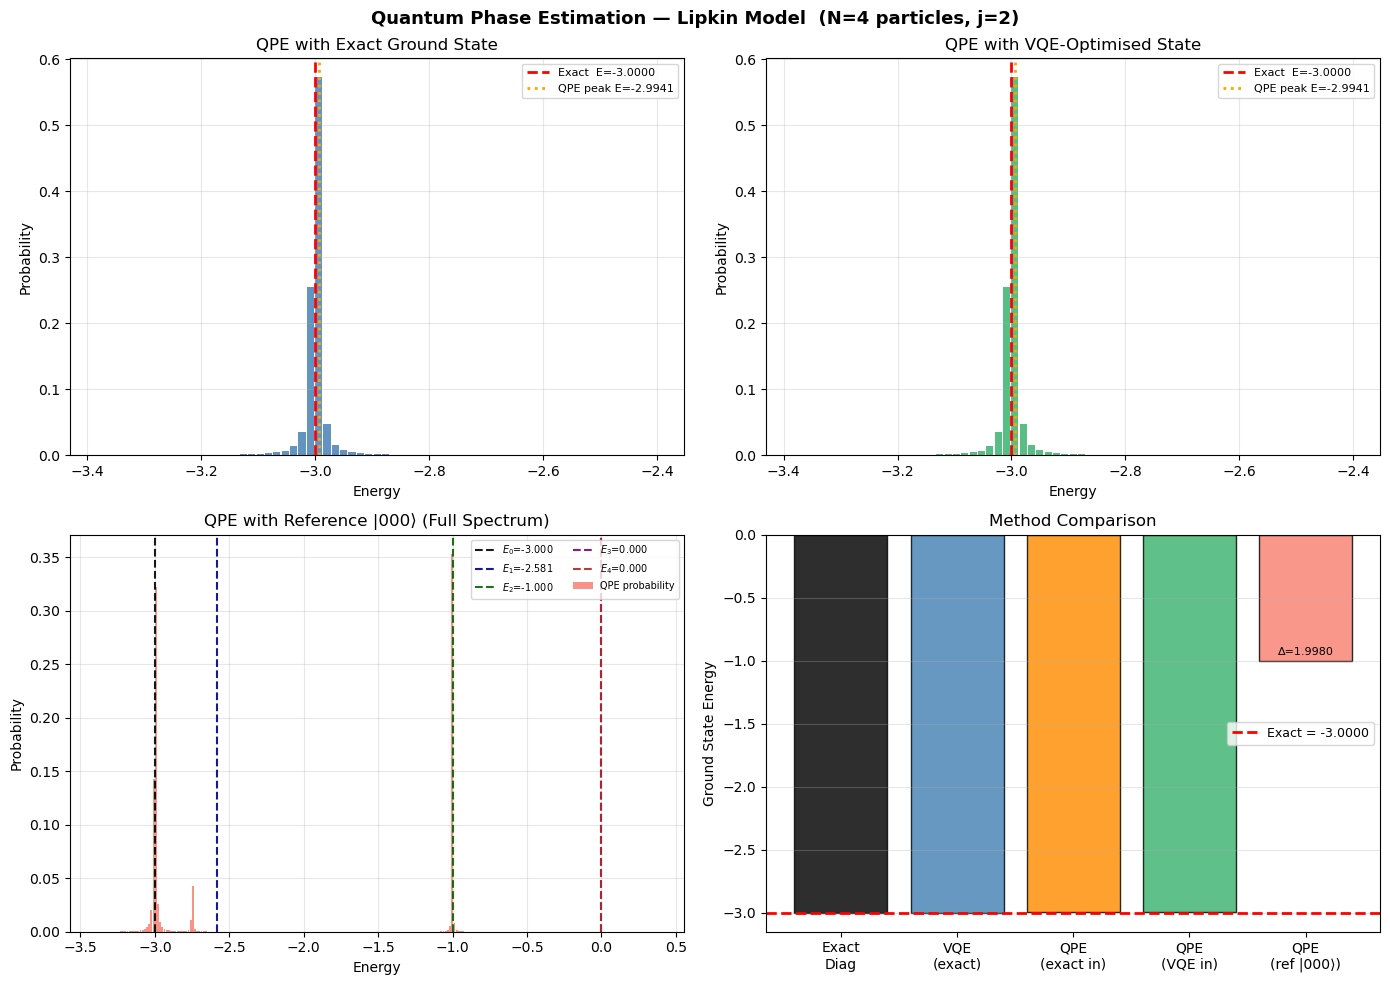

Figure saved: qpe_lipkin_results.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Quantum Phase Estimation — Lipkin Model  (N=4 particles, j=2)',
             fontsize=13, fontweight='bold')

# Energy axis for all bins
bins_axis   = np.arange(N_ancilla)
energy_axis = bins_axis / N_ancilla * (2 * np.pi / t_evolve) - shift
E_window    = 0.6   # zoom window around ground state for panels 1 and 2
mask        = np.abs(energy_axis - eigenvalues[0]) < E_window
ev_colors   = ['k', 'navy', 'darkgreen', 'purple', 'brown']

# ── Panel 1: Exact ground-state input ────────────────────────────────────────
ax = axes[0, 0]
ax.bar(energy_axis[mask], probs_exact[mask],
       width=E_resolution * 0.85, color='steelblue', alpha=0.85)
ax.axvline(E_exact,     color='red',    lw=2, ls='--', label=f'Exact  E={E_exact:.4f}')
ax.axvline(E_qpe_exact, color='orange', lw=2, ls=':',  label=f'QPE peak E={E_qpe_exact:.4f}')
ax.set_xlabel('Energy'); ax.set_ylabel('Probability')
ax.set_title('QPE with Exact Ground State')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 2: VQE-state input ──────────────────────────────────────────────────
ax = axes[0, 1]
ax.bar(energy_axis[mask], probs_vqe[mask],
       width=E_resolution * 0.85, color='mediumseagreen', alpha=0.85)
ax.axvline(E_exact,   color='red',    lw=2, ls='--', label=f'Exact  E={E_exact:.4f}')
ax.axvline(E_qpe_vqe, color='orange', lw=2, ls=':',  label=f'QPE peak E={E_qpe_vqe:.4f}')
ax.set_xlabel('Energy'); ax.set_ylabel('Probability')
ax.set_title('QPE with VQE-Optimised State')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 3: Reference state — full spectrum ──────────────────────────────────
ax = axes[1, 0]
ax.bar(energy_axis, probs_ref,
       width=E_resolution * 0.85, color='salmon', alpha=0.85, label='QPE probability')
for i, (Ev, col) in enumerate(zip(eigenvalues[:5], ev_colors)):
    ax.axvline(Ev, color=col, lw=1.5, ls='--', alpha=0.9, label=f'$E_{i}$={Ev:.3f}')
ax.set_xlabel('Energy'); ax.set_ylabel('Probability')
ax.set_title('QPE with Reference |000\u27e9 (Full Spectrum)')
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

# ── Panel 4: Method comparison bar chart ─────────────────────────────────────
ax = axes[1, 1]
methods      = ['Exact\nDiag', 'VQE\n(exact)', 'QPE\n(exact in)',
                 'QPE\n(VQE in)', 'QPE\n(ref |000\u27e9)']
energies_all = [E_exact, E_vqe_exact, E_qpe_exact, E_qpe_vqe, E_qpe_ref]
errors_all   = [0, abs(E_vqe_exact-E_exact),
                abs(E_qpe_exact-E_exact), abs(E_qpe_vqe-E_exact), abs(E_qpe_ref-E_exact)]
bar_colors   = ['black', 'steelblue', 'darkorange', 'mediumseagreen', 'salmon']
bars = ax.bar(methods, energies_all, color=bar_colors, alpha=0.82, edgecolor='k')
ax.axhline(E_exact, color='red', lw=2, ls='--', label=f'Exact = {E_exact:.4f}')
for bar, err in zip(bars, errors_all):
    if err > E_resolution / 2:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.03,
                f'\u0394={err:.4f}', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('Ground State Energy')
ax.set_title('Method Comparison')
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('qpe_lipkin_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: qpe_lipkin_results.png')


## Quantum Fourier Transform — Detailed Verification

In [16]:
print('Quantum Fourier Transform — Verification Suite')
print('='*60)

# ── 1. Unitarity for several sizes ───────────────────────────────────────────
print('1. Unitarity (QFT @ QFT† = I):')
for Nt in [2, 4, 8, 16, 32]:
    Q = qft_matrix(Nt)
    print(f'   N={Nt:2d}: {np.allclose(Q @ Q.conj().T, np.eye(Nt), atol=1e-12)}')

# ── 2. IQFT inverts QFT ───────────────────────────────────────────────────────
print('\n2. IQFT inverts QFT:')
v = np.random.randn(16) + 1j*np.random.randn(16); v /= np.linalg.norm(v)
Q16 = qft_matrix(16); IQ16 = iqft_matrix(16)
print(f'   IQFT(QFT(v)) == v: {np.allclose(IQ16 @ Q16 @ v, v, atol=1e-12)}')

# ── 3. QFT basis-state action ─────────────────────────────────────────────────
print('\n3. QFT|k> = (1/sqrt(N)) sum_j exp(2pi i jk/N)|j>:')
N_test = 8; Q8 = qft_matrix(N_test)
for k in [0, 2, 5, 7]:
    ek = np.zeros(N_test); ek[k] = 1.0
    Qek = Q8 @ ek
    expected = np.array([np.exp(2j*np.pi*j*k/N_test) for j in range(N_test)]) / np.sqrt(N_test)
    print(f'   k={k}: {np.allclose(Qek, expected, atol=1e-12)}')

# ── 4. IQFT peak-recovery: maps phase state to |bin> ─────────────────────────
print('\n4. IQFT peak recovery — (1/sqrt(N)) sum_k exp(i*theta*k)|k>  ->  |round(phi*N)>:')
N_test = 32; IQ = iqft_matrix(N_test)
for k_true in [0, 5, 16, 31]:
    phi_t = k_true / N_test
    phase_state = np.exp(2j*np.pi*np.arange(N_test)*phi_t) / np.sqrt(N_test)
    out = IQ @ phase_state
    k_meas = int(np.argmax(np.abs(out)**2))
    print(f'   True bin={k_true:2d}  Measured bin={k_meas:2d}  Correct={k_meas==k_true}')

# ── 5. QPE fidelity vs ancilla bits ──────────────────────────────────────────
print('\n5. QPE energy accuracy vs number of ancilla bits (exact ground state input):')
print(f'   {"n_anc":>5s}  {"N bins":>7s}  {"E_QPE":>10s}  {"Error":>10s}  {"Resolution":>12s}')
for na in [3, 4, 5, 6, 7, 8]:
    Na = 2**na
    # Quick noiseless QPE with fewer ancilla bits
    state_a = np.kron(np.ones(Na, dtype=complex)/np.sqrt(Na), psi_exact)
    for kk in range(na):
        U_kk = sp_expm(+1j * H_shift * t_evolve * (2**kk))
        sm_a = state_a.reshape(Na, N_system)
        out_a = sm_a.copy()
        for ai in range(Na):
            if (ai >> kk) & 1: out_a[ai, :] = U_kk @ sm_a[ai, :]
        state_a = out_a.ravel()
    IQa = iqft_matrix(Na)
    sm_a = state_a.reshape(Na, N_system)
    prob_a = np.real(np.sum(np.abs(IQa @ sm_a)**2, axis=1))
    kp_a = int(np.argmax(prob_a))
    Eq_a = kp_a / Na * (2*np.pi/t_evolve) - shift
    res_a = 2*np.pi / (t_evolve * Na)
    print(f'   {na:5d}  {Na:7d}  {Eq_a:10.6f}  {abs(Eq_a-E_exact):10.6f}  {res_a:12.6f}')


Quantum Fourier Transform — Verification Suite
1. Unitarity (QFT @ QFT† = I):
   N= 2: True
   N= 4: True
   N= 8: True
   N=16: True
   N=32: True

2. IQFT inverts QFT:
   IQFT(QFT(v)) == v: True

3. QFT|k> = (1/sqrt(N)) sum_j exp(2pi i jk/N)|j>:
   k=0: True
   k=2: True
   k=5: True
   k=7: True

4. IQFT peak recovery — (1/sqrt(N)) sum_k exp(i*theta*k)|k>  ->  |round(phi*N)>:
   True bin= 0  Measured bin= 0  Correct=True
   True bin= 5  Measured bin= 5  Correct=True
   True bin=16  Measured bin=16  Correct=True
   True bin=31  Measured bin=31  Correct=True

5. QPE energy accuracy vs number of ancilla bits (exact ground state input):
   n_anc   N bins       E_QPE       Error    Resolution
       3        8   -2.906250    0.093750      0.468750
       4       16   -2.906250    0.093750      0.234375
       5       32   -3.023438    0.023438      0.117188
       6       64   -3.023438    0.023438      0.058594
       7      128   -2.994141    0.005859      0.029297
       8      256   